In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("telco_data.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
### Information about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
### finding missing values

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

In [7]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner              999
Dependents             0
tenure              2497
PhoneService           0
MultipleLines          0
InternetService      999
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1498
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1498
TotalCharges           0
Churn                  0
dtype: int64

In [8]:
### Filling null values for object by mode and numbers by mean
print(df["gender"].unique())
print(df["Partner"].unique())
print(df["tenure"].unique())
print(df["InternetService"].unique())
print(df["StreamingTV"].unique())
print(df["MonthlyCharges"].unique())

['Female' 'Male' nan]
['Yes' 'No' nan]
[ 1. 34.  2. 45.  8. 22. 10. nan 62. 13. 16. 49. 52. 12. 30. 72. 27.  5.
 11. 17. 69. 25. 60. 18. 63. 47.  9. 31. 50. 64.  3. 46.  7. 42. 35. 29.
 66. 68. 43. 36. 41. 56. 33. 71. 23. 57. 65. 70.  6. 14. 20. 53.  4. 32.
 15. 40. 59. 44. 61. 24. 51. 67. 19. 21. 48. 38. 54. 28. 58. 37. 55. 39.
 26.]
['DSL' 'Fiber optic' 'No' nan]
['No' 'Yes' nan 'No internet service']
[29.85 56.95 53.85 ... 60.4  44.2  78.7 ]


In [9]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["Partner"] = df["Partner"].fillna(df["Partner"].mode()[0])
df["tenure"] = df["tenure"].fillna(df["tenure"].median())
df["InternetService"] = df["InternetService"].fillna(df["InternetService"].mode()[0])
df["StreamingTV"] = df["StreamingTV"].fillna(df["StreamingTV"].mode()[0])
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].mean())

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
print(df["gender"].unique())
print(df["Partner"].unique())
print(df["tenure"].unique())
print(df["InternetService"].unique())
print(df["StreamingTV"].unique())
print(df["MonthlyCharges"].unique())

['Female' 'Male']
['Yes' 'No']
[ 1. 34.  2. 45.  8. 22. 10. 29. 62. 13. 16. 49. 52. 12. 30. 72. 27.  5.
 11. 17. 69. 25. 60. 18. 63. 47.  9. 31. 50. 64.  3. 46.  7. 42. 35. 66.
 68. 43. 36. 41. 56. 33. 71. 23. 57. 65. 70.  6. 14. 20. 53.  4. 32. 15.
 40. 59. 44. 61. 24. 51. 67. 19. 21. 48. 38. 54. 28. 58. 37. 55. 39. 26.]
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
[29.85 56.95 53.85 ... 60.4  44.2  78.7 ]


In [12]:
### finding duplicated rows

df.drop_duplicates().isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
### seperates it as two columns
num_col=df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]]
cat_col=df.drop(columns=["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"])

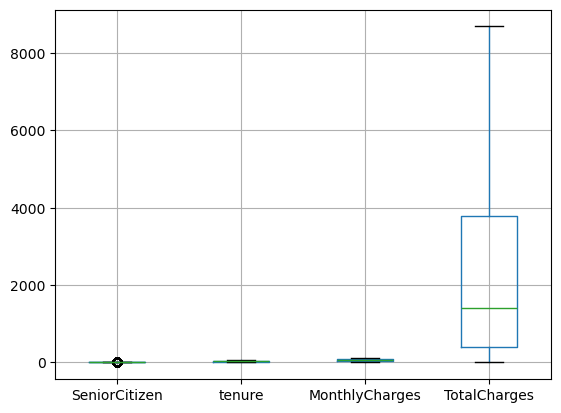

In [14]:
### Finding Outliers
num_col.boxplot()
plt.show()


In [15]:
### There is no outliers present in the  num_col 
### the seniorcitizen colunm only having two numbers(0,1) it is discrete colunm

In [16]:
### one hot encoder for labelling text into numbers

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   float64
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [18]:
### Drop the Customer ID because it doesnt realtable to the Churn
df=df.drop(columns="customerID")

In [19]:
cat_col= df.select_dtypes(include=['object']).columns.tolist()

# 2. Apply One-Hot Encoding
# pd.get_dummies handles index alignment, column naming, and conversion automatically.
# drop_first=True prevents multicollinearity.
df_encoded = pd.get_dummies(df, columns=cat_col, drop_first=True)

df.drop(cat_col,axis=1)
df=pd.concat([num_col,df_encoded], axis=1)

In [20]:
std_sca=StandardScaler()

In [21]:
num_cols=std_sca.fit_transform(num_col)

In [22]:
num_cols

array([[-0.44032709, -1.53622453, -1.31404751, -0.99419409],
       [-0.44032709,  0.13555431, -0.29874663, -0.17373982],
       [-0.44032709, -1.48556456, -0.41488806, -0.95964911],
       ...,
       [-0.44032709, -1.02962488, -1.32341375, -0.85451414],
       [ 2.27103902, -0.11774552,  0.35501721, -0.87209546],
       [-0.44032709,  1.75667318,  1.52579774,  2.01234407]])

In [23]:
df.drop(num_col,axis=1)
num_cols_df = pd.DataFrame(num_cols)  # You might need to specify column names here
df=pd.concat([num_cols_df,df_encoded], axis=1)

In [24]:
df

,0,1,2,3,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,-0.440327,-1.536225,-1.314048,-0.994194,0.0,1.0,29.85,29.85,False,True,...,False,False,False,False,False,True,False,True,False,False
1,-0.440327,0.135554,-0.298747,-0.173740,0.0,34.0,56.95,1889.50,True,False,...,False,False,False,True,False,False,False,False,True,False
2,-0.440327,-1.485565,-0.414888,-0.959649,0.0,2.0,53.85,108.15,True,False,...,False,False,False,False,False,True,False,False,True,True
3,-0.440327,0.692814,-0.847609,-0.195248,0.0,45.0,42.30,1840.75,True,False,...,False,False,False,True,False,False,False,False,False,False
4,-0.440327,-1.485565,0.216397,-0.940457,0.0,2.0,70.70,151.65,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,NaN,NaN,NaN,NaN,0.0,24.0,84.80,1990.50,True,True,...,True,False,True,True,False,True,False,False,True,False
7039,NaN,NaN,NaN,NaN,0.0,72.0,103.20,7362.90,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,NaN,NaN,NaN,NaN,0.0,11.0,29.60,346.45,False,True,...,False,False,False,False,False,True,False,True,False,False
7041,NaN,NaN,NaN,NaN,1.0,29.0,74.40,306.60,True,True,...,False,False,False,False,False,True,False,False,True,True
